In [1]:
import json, zipfile, numpy as np, os
from PIL import Image as PILImage, ImageDraw

DATA = "data"
IMAGES = "images"

with zipfile.ZipFile(f"{DATA}/vg150/annotations/relationships_v1_2.json.zip", 'r') as zf:
    with zf.open('relationships.json') as f:
        v12 = json.load(f)

picks = [75661, 75704, 75655, 75654, 75703, 75668, 75657]
vg_ids = [2343723, 2343675, 2343729, 2343730, 2343676, 2343715, 2343727]

colors = ['red','lime','yellow','blue','orange','purple',
          'cyan','magenta','limegreen','pink','teal','lavender',
          'brown','cornsilk','maroon']

print(f"v1.2 loaded: {len(v12)} images")
for i, (h5_idx, vg_id) in enumerate(zip(picks, vg_ids)):
    img_path = f"{IMAGES}/{vg_id}.jpg"
    ok = "photo" if os.path.exists(img_path) else "MISSING"
    entry = v12[h5_idx]
    n_rel = len(entry.get('relationships', []))
    print(f"  test{i+1}: h5={h5_idx} vg={vg_id} rels={n_rel} {ok}")


v1.2 loaded: 108077 images
  test1: h5=75661 vg=2343723 rels=28 photo
  test2: h5=75704 vg=2343675 rels=27 photo
  test3: h5=75655 vg=2343729 rels=15 photo
  test4: h5=75654 vg=2343730 rels=40 photo
  test5: h5=75703 vg=2343676 rels=35 photo
  test6: h5=75668 vg=2343715 rels=45 photo
  test7: h5=75657 vg=2343727 rels=19 photo


In [2]:

def draw_v12(h5_idx, label):
    entry = v12[h5_idx]
    vg_id = vg_ids[picks.index(h5_idx)]
    img_path = f"{IMAGES}/{vg_id}.jpg"

    if not os.path.exists(img_path):
        print(f"{label}: MISSING PHOTO")
        return None

    img = PILImage.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img, 'RGBA')

    objs = {}
    for rel in entry.get('relationships', []):
        for side in ('subject', 'object'):
            obj = rel.get(side, {})
            oid = obj.get('object_id')
            if oid and oid not in objs:
                x = obj.get('x', 0)
                y = obj.get('y', 0)
                w = obj.get('w', 0)
                h = obj.get('h', 0)
                name = obj.get('name', '?')
                if isinstance(name, list): name = name[0] if name else '?'
                objs[oid] = (x, y, w, h, str(name))

    for i, (oid, (x, y, w, h, name)) in enumerate(objs.items()):
        if w <= 0 or h <= 0:
            continue
        color = colors[i % len(colors)]
        draw.rectangle([x, y, x + w, y + h], outline=color, width=2)
        tw = len(name) * 7 + 6
        draw.rectangle([x, max(0, y - 14), x + tw, y], fill=color)
        draw.text((x + 3, max(0, y - 13)), name, fill='white')

    for rel in entry.get('relationships', []):
        subj = rel.get('subject', {})
        obj = rel.get('object', {})
        sid = subj.get('object_id')
        oid = obj.get('object_id')
        if sid not in objs or oid not in objs:
            continue
        sx, sy, sw, sh, _ = objs[sid]
        ox, oy, ow, oh, _ = objs[oid]
        cx1, cy1 = int(sx + sw/2), int(sy + sh/2)
        cx2, cy2 = int(ox + ow/2), int(oy + oh/2)
        pred = rel.get('predicate', '?').lower()
        draw.line([cx1, cy1, cx2, cy2], fill=(0, 255, 0, 128), width=2)
        mx, my = (cx1 + cx2) // 2, (cy1 + cy2) // 2
        pw = len(pred) * 7 + 4
        draw.rectangle([mx, my - 12, mx + pw, my], fill=(0, 255, 0, 200))
        draw.text((mx + 2, my - 11), pred[:10], fill='black')

    n_rel = len(entry.get('relationships', []))
    print(f"{label}: {len(objs)} objs, {n_rel} rels")
    return img


test1: 38 objs, 28 rels


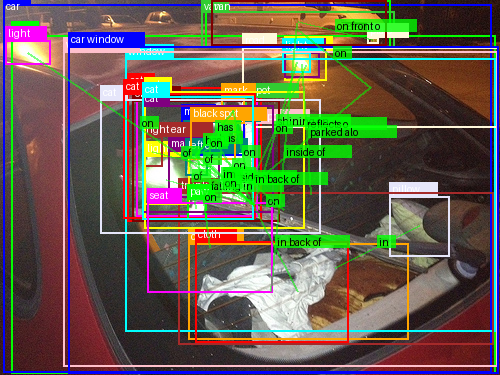

In [3]:
img = draw_v12(75661, 'test1')
if img: display(img)

test2: 47 objs, 27 rels


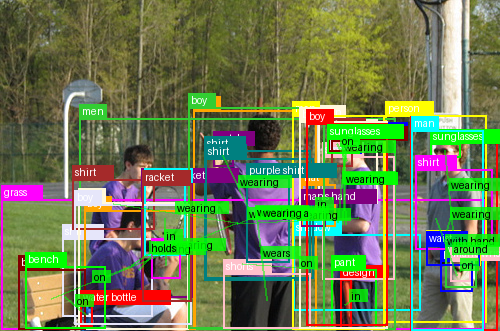

In [4]:
img = draw_v12(75704, 'test2')
if img: display(img)

test3: 15 objs, 15 rels


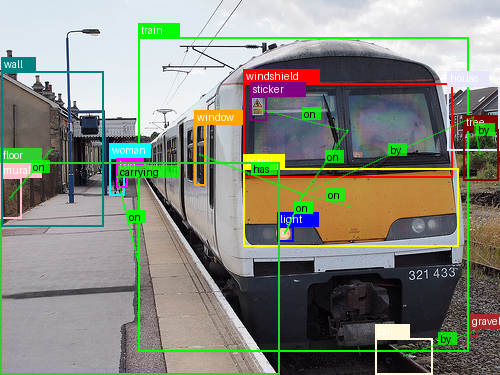

In [5]:
img = draw_v12(75655, 'test3')
if img: display(img)

test4: 59 objs, 40 rels


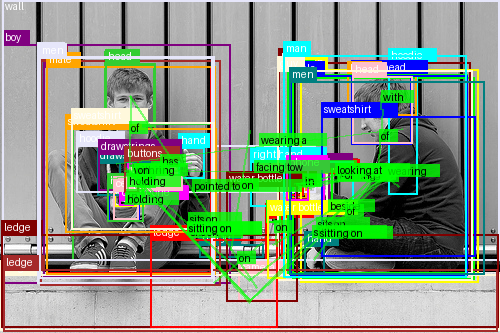

In [6]:
img = draw_v12(75654, 'test4')
if img: display(img)

test5: 28 objs, 35 rels


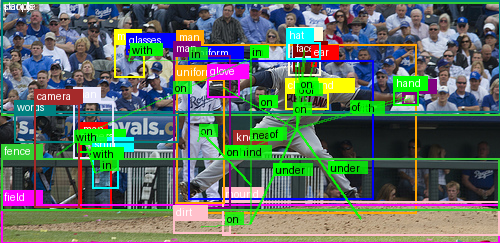

In [7]:
img = draw_v12(75703, 'test5')
if img: display(img)

test6: 70 objs, 45 rels


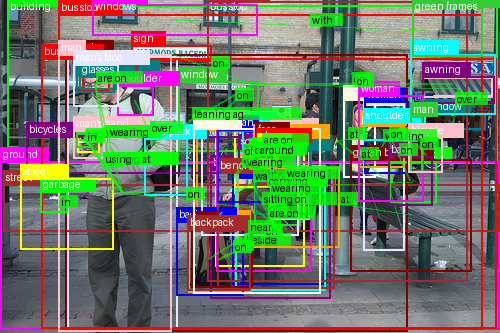

In [8]:
img = draw_v12(75668, 'test6')
if img: display(img)

test7: 35 objs, 19 rels


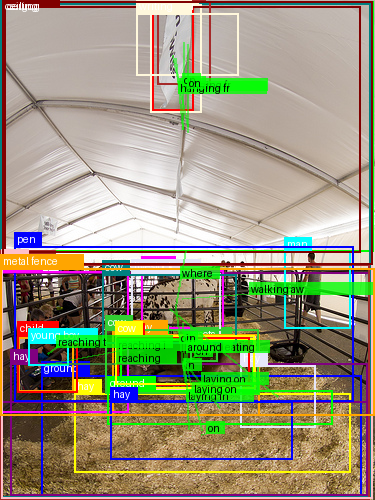

In [9]:
img = draw_v12(75657, 'test7')
if img: display(img)